# Iris recognition with SONN

Notebook port of `iri_recognition.py`. Trains a self-organizing polynomial neural network on the classic Iris dataset and renders all diagnostics (confusion matrix, per-layer error curve, full ensemble graph, pruned best-path graph) inline.

All on-disk side effects (training checkpoints, log file, graphviz `.dot` / `.svg` intermediates) are routed to a per-run temporary directory — **nothing is written into this folder**.

## Imports & matplotlib backend

`%matplotlib inline` puts plots in the cell output. `sys.path` insert lets us `from torchsonn.* import ...` regardless of where Jupyter was launched (assumes the notebook still sits under `tutorials/iris/`).

In [16]:
%matplotlib inline

import os
import sys
import tempfile
from pathlib import Path

# Make the project's `src/` importable when the notebook is launched from
# anywhere (e.g. `jupyter lab` from the project root or from this folder).
project_root = Path.cwd()
while not (project_root / 'src').is_dir() and project_root != project_root.parent:
    project_root = project_root.parent
# Src layout: the importable `torchsonn` package lives inside `src/`. Adding
# `src/` to sys.path lets the notebook work without `pip install -e .`;
# if the package IS installed editably, this entry is just harmless duplication.
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
import hydra
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from IPython.display import display

from torchsonn.data.dataset import SONNDataset
from torchsonn.data.preprocessing import train_preprocessing
from torchsonn.logger import setup_logger
from torchsonn.model import SONN
from torchsonn.plot_model import PlotModel
from torchsonn.trainer import Trainer


## Scratch directory

Everything that would normally hit `tutorials/iris/` (training checkpoints, log file, graphviz render targets) goes here. The directory is created up-front so we can pass concrete paths down; clean it up manually with `shutil.rmtree(tmp_dir)` once you're done.

In [17]:
# Notebook outputs are committed to the repo, so anything printed below is
# published with it. Raw absolute paths leak the OS account name (on Windows
# the temp dir is C:\Users\<name>\AppData\Local\Temp), where the project sits
# on disk, and - if the repo lives on a mapped network drive - the file
# server's hostname and share. Route anything that may embed a path through
# redact() before printing or logging it.
import re

# Longest-first: on Windows the temp dir is *inside* the home dir, so it has
# to be substituted before the home-dir rule can shorten its prefix to '~'.
_REDACTIONS = [
    (tempfile.gettempdir(), '<tmp>'),
    (str(project_root.resolve()), '<repo>'),  # UNC form of a mapped drive
    (str(project_root), '<repo>'),            # the mapped drive itself
    (str(Path.home()), '~'),
]


def redact(text: object) -> str:
    """Swap machine-specific path prefixes for stable placeholders."""
    s = str(text)
    for real, label in _REDACTIONS:
        # Match both separator styles: pathlib emits '\', YAML dumps often '/'.
        for variant in {real, real.replace('\\', '/')}:
            s = re.sub(re.escape(variant), label, s, flags=re.IGNORECASE)
    return s

tmp_dir = Path(tempfile.mkdtemp(prefix='iris_sonn_'))
ckpt_dir = tmp_dir / 'checkpoints'
ckpt_dir.mkdir(exist_ok=True)
log_path = str(tmp_dir / 'train.log')
print(f'scratch dir : {redact(tmp_dir)}')
print(f'checkpoints : {redact(ckpt_dir)}')
print(f'log file    : {redact(log_path)}')

scratch dir : <tmp>\iris_sonn_xeaxyxr3
checkpoints : <tmp>\iris_sonn_xeaxyxr3\checkpoints
log file    : <tmp>\iris_sonn_xeaxyxr3\train.log


## Load config

Reads `iris.yaml` from the same folder and overrides `train.checkpoint_dir` so the checkpoints land in the scratch dir instead of the repo's `checkpoints/`.

In [18]:
# Hydra's compose API loads the same YAML the CLI entry point uses,
# without invoking @hydra.main (no working-dir change, no per-run outputs/
# directory).
#
# Self-bootstrap: explicitly import torchsonn.config so its side-effect
# ConfigStore.store(name='default', node=SONNConfig) runs before compose.
# Cell 2's `from torchsonn.model import SONN` triggers the same chain, but this
# guards against running cell 6 standalone (e.g. after a kernel restart).
import torchsonn.config  # noqa: F401 — side-effect: ConfigStore registration

# We intentionally do not pass overrides=[f'train.checkpoint_dir={ckpt_dir}']:
# Hydra's override grammar treats ':' and backslash as reserved tokens, so a
# Windows path like 'C:/Users/<name>/Temp/iris_sonn_xxx/checkpoints' trips its
# lexer. Setting the field by attribute on the composed config bypasses the
# grammar entirely. For non-path overrides, the Hydra CLI form still works:
#     compose(config_name='iris', overrides=['train.steps=2000', 'resume=true'])
config_dir = (project_root / 'tutorials' / 'iris').resolve()
with initialize_config_dir(version_base='1.3', config_dir=str(config_dir)):
    config = compose(config_name='iris')

# Send checkpoints to the per-run scratch dir.
config.train.checkpoint_dir = str(ckpt_dir)

logger = setup_logger(log_path)
logger.info('Loaded config:')
logger.info(redact(OmegaConf.to_yaml(config)))
redact(OmegaConf.to_yaml(config)).splitlines()[:8]  # peek

2026-07-18 16:31:04,057 - INFO - root - Loaded config:
2026-07-18 16:31:04,060 - INFO - root - model:
  type: multi-class
  soft_binner: false
  soft_binner_scale: 100.0
  num_classes: 3
  ref_functions:
  - linear_cov:
      activation: ''
  shortcut: false
  normalize: true
  nbest_neurons: 4
  max_neuron_models: 8
  use_output_projection: false
  num_out_neurons: null
  use_neuron_proj: false
  output_clamp_value: 1000.0
  use_layer_norm: false
train:
  seed: 10
  criterion_type: validate
  bias_ce_type: js
  error_alpha: 0.5
  max_layer_count: 5
  criterion_minimum_width: 5
  stop_train_epsilon_condition: 1.0e-06
  manual_best_neurons_selection: false
  min_best_neurons_count: 0
  max_best_neurons_count: 0
  layer_err_criterion: top
  neuron_selection_method: plain
  neuron_selection_orth_threshold: 0.3
  eval_step_interval: 5
  eval_smoothing_factor: 0.2
  save_interval: 100
  save_last_layer: true
  keep_last_n: 100
  skip_saving_at_epoch_end: true
  checkpoint_dir: <tmp>\iris_so

['model:',
 '  type: multi-class',
 '  soft_binner: false',
 '  soft_binner_scale: 100.0',
 '  num_classes: 3',
 '  ref_functions:',
 '  - linear_cov:',
 "      activation: ''"]

## Load Iris

Re-interleaves rows so that the eventual 70/15/15 prefix slice has all three classes represented (the raw sklearn ordering puts each species in a contiguous block of 50).

In [19]:
iris = load_iris()
iris.data = iris.data.astype(np.float32)

n_samples = iris.data.shape[0]
data = np.empty_like(iris.data)
target = np.empty_like(iris.target)
n = n_samples // 3
j = 0
for i in range(0, n):
    data[j]   = iris.data[i]
    data[j+1] = iris.data[i+n]
    data[j+2] = iris.data[i+2*n]
    target[j]   = iris.target[i]
    target[j+1] = iris.target[i+n]
    target[j+2] = iris.target[i+2*n]
    j += 3

print(f'samples : {data.shape[0]}')
print(f'features: {data.shape[1]}')
print(f'classes : {sorted(set(target.tolist()))}  → {iris.target_names.tolist()}')

samples : 150
features: 4
classes : [0, 1, 2]  → ['setosa', 'versicolor', 'virginica']


## Train / dev / test split

70 / 15 / 15 by index. Dev set is used by `train_layer`'s `validate` criterion to score each candidate neuron.

In [20]:
indices = np.arange(data.shape[0])
train_size = int(0.7 * data.shape[0])
dev_size   = int(0.15 * data.shape[0])

train_idx = indices[:train_size]
dev_idx   = indices[train_size:train_size + dev_size]
test_idx  = indices[train_size + dev_size:]

x_train, y_train = data[train_idx], target[train_idx]
x_dev,   y_dev   = data[dev_idx],   target[dev_idx]
x_test,  y_test  = data[test_idx],  target[test_idx]

x_train, y_train = train_preprocessing(x_train, y_train, iris.feature_names)
x_dev,   y_dev   = train_preprocessing(x_dev,   y_dev,   iris.feature_names)
x_test,  y_test  = train_preprocessing(x_test,  y_test,  iris.feature_names)

print(f'train: {x_train.shape}  dev: {x_dev.shape}  test: {x_test.shape}')

train: (105, 4)  dev: (22, 4)  test: (23, 4)


## Datasets & loaders

Three `SONNDataset`s wrapped in vanilla PyTorch `DataLoader`s. Batch size comes from the YAML.

In [21]:
train_ds = SONNDataset(x_train, y_train)
dev_ds   = SONNDataset(x_dev,   y_dev)
test_ds  = SONNDataset(x_test,  y_test)

train_dl = DataLoader(train_ds, batch_size=config.train.batch_size, shuffle=True)
dev_dl   = DataLoader(dev_ds,   batch_size=config.train.batch_size)
test_dl  = DataLoader(test_ds,  batch_size=config.train.batch_size)

## Build the SONN model

`d_model` is just the input feature count. `feature_names` flows into the `PlotModel` output so input nodes are labeled (`sepal length`, etc.) instead of `F0..F3`.

In [22]:
model = SONN(
    config,
    d_model=x_train.shape[1],
    feature_names=iris.feature_names,
)
model = model.to(config.train.device)
model

SONN(
  (layers): ModuleList()
  (shared_proj): Linear(in_features=1, out_features=3, bias=True)
  (loss_fn): NLLLoss()
)

## Train

Layers are built incrementally; growth stops automatically once `stop_train_epsilon_condition` × `criterion_minimum_width` says we've plateaued. `tqdm`'s progress bar tracks the global LBFGS / Adam step budget per layer.

In [23]:
trainer = Trainer(config, feature_names=iris.feature_names)
trainer.set_seed(model.param.train.seed)

trainer.train(model, train_dl, dev_dl, test_dl, resume=False)

2026-07-18 16:31:04,193 - INFO - torchsonn.model - Creating layer #0
2026-07-18 16:31:04,194 - WARNING - torchsonn.neurons.base - generate_unique_pairs requested 8 pairs but only 6 unique pairs exist for n=4 (allow_self=False, ordered=False); clamping.
2026-07-18 16:31:04,194 - INFO - torchsonn.trainer - Training layer #0
2026-07-18 16:31:05,434 - INFO - torchsonn.trainer - All models of LinearCovPolynomNeuron early stopped at step 530                              
Training: 100%|██████████| 530/530 [00:01<00:00, 427.41it/s, epoch=132, step=530, lr=6.25e-06, val_loss=[0.087, 210.386, 630.190], completed=5/6]
2026-07-18 16:31:05,445 - INFO - torchsonn.trainer - Current layer error: 0.079
2026-07-18 16:31:05,445 - INFO - torchsonn.trainer - Layer errors: [0.079]
2026-07-18 16:31:05,564 - INFO - torchsonn.utils - Executed train layer #0 in 1.37 sec
2026-07-18 16:31:05,564 - INFO - torchsonn.model - Creating layer #1
2026-07-18 16:31:05,564 - WARNING - torchsonn.neurons.base - generate_uni

SONN(
  (layers): ModuleList(
    (0): Layer 0
  )
  (shared_proj): Linear(in_features=1, out_features=3, bias=True)
  (loss_fn): NLLLoss()
)

## Restore best checkpoint & infer on the test split

In [24]:
trainer.load_model_checkpoint(model, config.train.device)
model_out, test_targets = trainer.infer(model, test_dl)

pred_y = model_out.argmax(dim=1).cpu().numpy()
test_y = test_targets.cpu().numpy()
accuracy = float((pred_y == test_y).mean())
print(f'test accuracy: {accuracy:.4f}')

1it [00:00, 1203.19it/s]

test accuracy: 1.0000


## Selected vs. unselected features

Walks the trained network's `src_idxs` to figure out which of the 4 original Iris features actually feed any surviving neuron.

In [25]:
print(f'selected indices  : {model.get_selected_features_indices()}')
print(f'unselected indices: {model.get_unselected_features_indices()}')
print(f'selected features : {model.get_selected_features()}')
print(f'unselected        : {model.get_unselected_features()}')

selected indices  : [0, 1, 2, 3]
unselected indices: []
selected features : sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
unselected        : No unselected features


## Confusion matrix

Raw counts on the left, row-normalized on the right. The 70/15/15 split keeps ~22 test samples spread across the 3 classes.

Confusion matrix, without normalization
[[7 0 0]
 [0 8 0]
 [0 0 8]]
Normalized confusion matrix
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


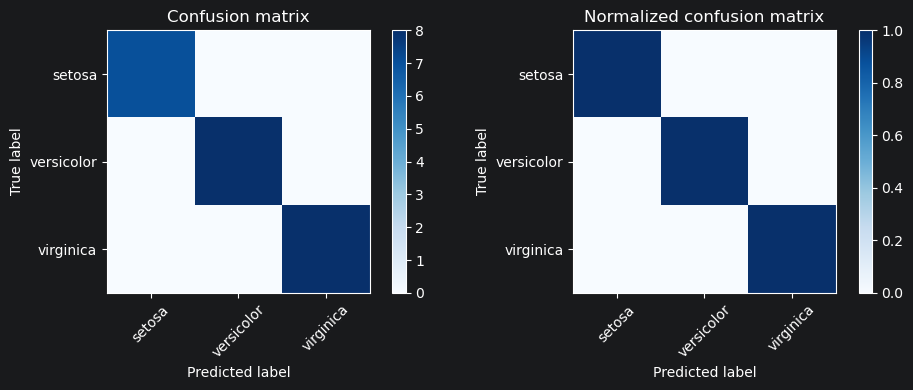

In [26]:
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(iris.target_names))
    plt.xticks(tick_marks, iris.target_names, rotation=45)
    plt.yticks(tick_marks, iris.target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

fig = plt.figure(figsize=(10, 4))
cm = confusion_matrix(test_y, pred_y)
np.set_printoptions(precision=2)
print('Confusion matrix, without normalization')
print(cm)
ax1 = fig.add_subplot(121)
plot_confusion_matrix(cm)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print('Normalized confusion matrix')
print(cm_norm)
ax2 = fig.add_subplot(122)
plot_confusion_matrix(cm_norm, title='Normalized confusion matrix')
plt.show()

## Layer-error curve

`model.layer_err[i]` is the layer-level criterion error (NormMSE for regressors, NLL-style otherwise) after each layer was added. The red diamond marks the chosen final layer.

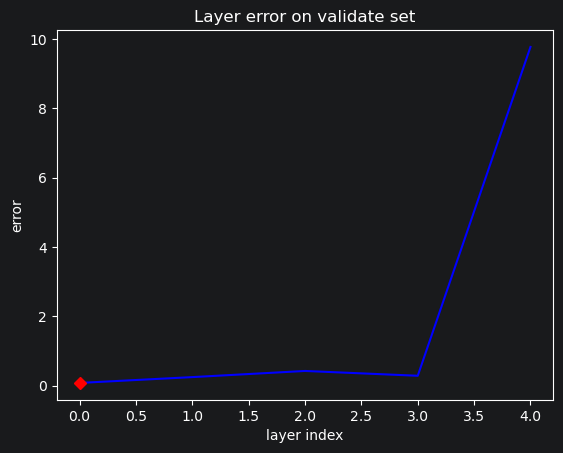

In [27]:
model.plot_layer_error()
plt.show()

## Plot the full ensemble (pre-prune)

`PlotModel(...).plot()` builds a graphviz `Digraph` of inputs → every surviving candidate neuron → `OUTPUT`. We pass a temp filename so its `render(...)` side-effect lands in the scratch dir; the cell's final expression is the digraph object itself, which Jupyter renders as an inline SVG via graphviz's `_repr_image_svg_xml_`.

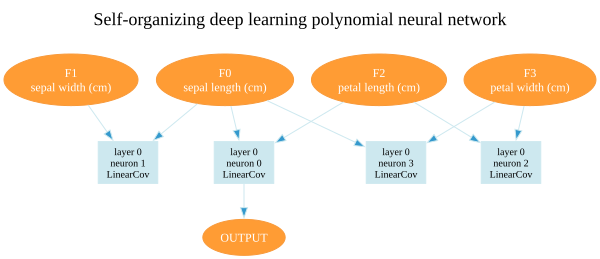

In [28]:
full_plot = PlotModel(
    model,
    filename=str(tmp_dir / 'iris_model'),
    plot_neuron_name=True,
    view=False,  # no GUI pop-up in notebooks
)
full_plot.plot()
full_plot.g  # ← inline-rendered SVG

## Prune to the single best path & plot again

`trainer.prune(model)` walks from the output layer backward: keeps the lowest-error neuron of the last layer, then iteratively keeps only the upstream neurons referenced by surviving src_idxs. Cascades through dead layers if shortcut connections render an intermediate layer unused.

1it [00:00, 931.03it/s]


pruned-model test accuracy: 1.0000
selected features after prune: sepal length (cm), petal length (cm)


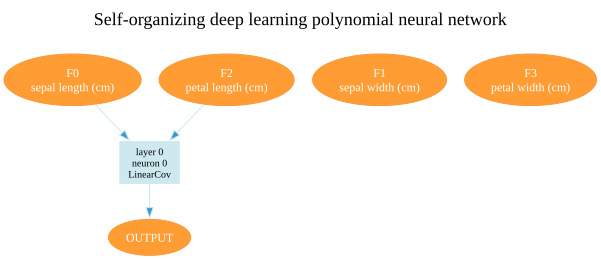

In [29]:
trainer.prune(model)

# Sanity: inference still works on the slimmed network.
model_out_pruned, _ = trainer.infer(model, test_dl)
pred_y_pruned = model_out_pruned.argmax(dim=1).cpu().numpy()
print(f'pruned-model test accuracy: {(pred_y_pruned == test_y).mean():.4f}')
print(f'selected features after prune: {model.get_selected_features()}')

pruned_plot = PlotModel(
    model,
    filename=str(tmp_dir / 'iris_pruned_model'),
    plot_neuron_name=True,
    view=False,
)
pruned_plot.plot()
pruned_plot.g  # ← inline-rendered SVG

## Cleanup (optional)

Uncomment to nuke the per-run scratch directory once you're done browsing the outputs.

In [30]:
# import shutil
# shutil.rmtree(tmp_dir)
# print(f'removed {redact(tmp_dir)}')